In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

Mounted at /content/drive


In [2]:
BASE_PATH     = '/content/drive/MyDrive/FinalProject/new data'
METADATA_PATH = os.path.join(BASE_PATH, 'HAM10000_metadata.csv')
IMAGES_PATH   = os.path.join(BASE_PATH, 'images')
MODEL_DIR     = '/content/drive/MyDrive/FinalProject/models'
BEST_MODEL_V5 = os.path.join(MODEL_DIR, 'best_model_v5.pth')

os.makedirs(MODEL_DIR, exist_ok=True)


In [3]:
df = pd.read_csv(METADATA_PATH)
df = df.dropna(subset=["image_id"]).reset_index(drop=True)

suspicious_map = {
    "mel": 1, "bcc": 1, "akiec": 1,
    "nv": 0,  "bkl": 0, "df": 0, "vasc": 0
}
df["suspicious"] = df["dx"].map(suspicious_map)

train_df = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/train_df.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/val_df.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/test_df.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7010 | Val: 1502 | Test: 1503


In [4]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [5]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.fromarray(np.zeros((300,300,3), dtype=np.uint8))
        label = torch.tensor(int(row["suspicious"]), dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label, row["image_id"]

train_dataset = SkinDataset(train_df, IMAGES_PATH, train_transforms)
val_dataset   = SkinDataset(val_df,   IMAGES_PATH, val_transforms)
test_dataset  = SkinDataset(test_df,  IMAGES_PATH, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("Loaders ready!")

Loaders ready!


In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=2).to(device)

class_weights = torch.tensor([1.0, 4.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [7]:
# TRAINING LOOP - V5

EPOCHS = 20

history_v5 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss_v5 = float("inf")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{train_correct/train_total:.4f}"
        })

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels, _ in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_time = time.time() - start_time

    tl = train_loss / len(train_loader)
    vl = val_loss / len(val_loader)
    ta = train_correct / train_total
    va = val_correct / val_total

    history_v5["train_loss"].append(tl)
    history_v5["val_loss"].append(vl)
    history_v5["train_acc"].append(ta)
    history_v5["val_acc"].append(va)

    if vl < best_val_loss_v5:
        best_val_loss_v5 = vl
        torch.save(model.state_dict(), BEST_MODEL_V5)
        print("Saved best_model_v5.pth")

    print(f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f}")
    print(f"Val   Loss: {vl:.4f} | Val   Acc: {va:.4f}")
    print(f"Time: {epoch_time:.2f}s | LR: {scheduler.get_last_lr()[0]:.6f}")
    print("-" * 50)


Epoch 1/20


Saved best_model_v5.pth
Train Loss: 0.8433 | Train Acc: 0.7479
Val   Loss: 0.6075 | Val   Acc: 0.8023
Time: 3154.18s | LR: 0.000099
--------------------------------------------------

Epoch 2/20


Saved best_model_v5.pth
Train Loss: 0.4684 | Train Acc: 0.8087
Val   Loss: 0.4998 | Val   Acc: 0.8489
Time: 145.00s | LR: 0.000098
--------------------------------------------------

Epoch 3/20


Saved best_model_v5.pth
Train Loss: 0.3529 | Train Acc: 0.8417
Val   Loss: 0.4064 | Val   Acc: 0.8029
Time: 143.77s | LR: 0.000095
--------------------------------------------------

Epoch 4/20


Train Loss: 0.3030 | Train Acc: 0.8718
Val   Loss: 0.4096 | Val   Acc: 0.8462
Time: 143.98s | LR: 0.000090
--------------------------------------------------

Epoch 5/20


...

Train Loss: 0.0542 | Train Acc: 0.9810
Val   Loss: 0.5640 | Val   Acc: 0.9068
Time: 144.67s | LR: 0.000010
--------------------------------------------------

Epoch 17/20


Train Loss: 0.0452 | Train Acc: 0.9849
Val   Loss: 0.5334 | Val   Acc: 0.9081
Time: 144.17s | LR: 0.000005
--------------------------------------------------

Epoch 18/20


Train Loss: 0.0375 | Train Acc: 0.9882
Val   Loss: 0.5386 | Val   Acc: 0.9008
Time: 144.24s | LR: 0.000002
--------------------------------------------------

Epoch 19/20


Train Loss: 0.0358 | Train Acc: 0.9864
Val   Loss: 0.5715 | Val   Acc: 0.9061
Time: 144.69s | LR: 0.000001
--------------------------------------------------

Epoch 20/20


Train Loss: 0.0412 | Train Acc: 0.9880
Val   Loss: 0.5772 | Val   Acc: 0.9128
Time: 144.29s | LR: 0.000000
--------------------------------------------------


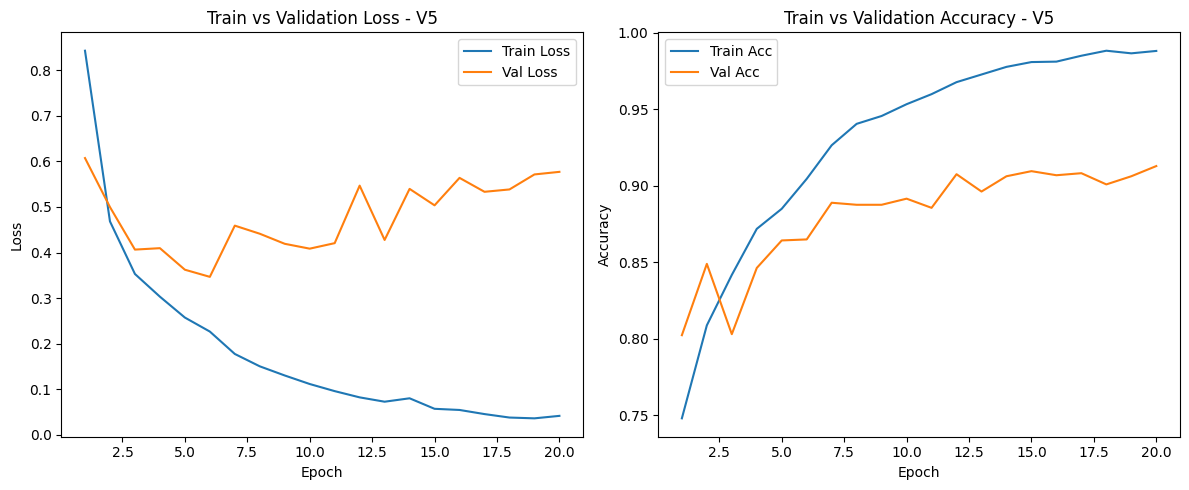

In [8]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_v5["train_loss"], label="Train Loss")
plt.plot(epochs, history_v5["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss - V5")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_v5["train_acc"], label="Train Acc")
plt.plot(epochs, history_v5["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy - V5")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
model.load_state_dict(torch.load(BEST_MODEL_V5, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\nTest Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=["Not Suspicious", "Suspicious"]))


Test Accuracy: 0.8530
                precision    recall  f1-score   support

Not Suspicious       0.96      0.85      0.90      1210
    Suspicious       0.58      0.85      0.69       293

      accuracy                           0.85      1503
     macro avg       0.77      0.85      0.80      1503
  weighted avg       0.89      0.85      0.86      1503

